## EDA - Прогнозирование успеваемости студентов

In [151]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings
from sklearn.preprocessing import LabelEncoder


In [152]:
data = pd.read_csv("../students.csv", sep=";")

## Исследование исходных данных

### Датасет содержит следующие поля:
1. Marital Status: 
    - 1 - single 
    - 2 – married 
    - 3 – widower 
    - 4 – divorced 
    - 5 – facto union 
    - 6 – legally separated
2. Application mode:
    - 1 - 1st phase - general contingent 
    - 2 - Ordinance No. 612/93 
    - 5 - 1st phase - special contingent (Azores Island) 
    - 7 - Holders of other higher courses 
    - 10 - Ordinance No. 854-B/99 
    - 15 - International student (bachelor) 
    - 16 - 1st phase - special contingent (Madeira Island) 
    - 17 - 2nd phase - general contingent 
    - 18 - 3rd phase - general contingent 
    - 26 - Ordinance No. 533-A/99, item b2 (Different Plan) 
    - 27 - Ordinance No. 533-A/99, item b3 (Other Institution) 
    - 39 - Over 23 years old 
    - 42 - Transfer 
    - 43 - Change of course 
    - 44 - Technological specialization diploma holders 
    - 51 - Change of institution/course 
    - 53 - Short cycle diploma holders 
    - 57 - Change of institution/course (International)
3. Application order:
    - between 0 - first choice; and 9 last choice
4. Course:
    - 33 - Biofuel Production Technologies 
    - 171 - Animation and Multimedia Design 
    - 8014 - Social Service (evening attendance) 
    - 9003 - Agronomy 
    - 9070 - Communication Design 
    - 9085 - Veterinary Nursing 
    - 9119 - Informatics Engineering 
    - 9130 - Equinculture 
    - 9147 - Management 
    - 9238 - Social Service 
    - 9254 - Tourism 
    - 9500 - Nursing 
    - 9556 - Oral Hygiene 
    - 9670 - Advertising and Marketing Management 
    - 9773 - Journalism and Communication 
    - 9853 - Basic Education 
    - 9991 - Management (evening attendance)	
5. Daytime/evening attendance:
    - 1 – daytime 
    - 0 - evening
6. Previous qualification:
    - 1 - Secondary education 
    - 2 - Higher education - bachelor's degree 
    - 3 - Higher education - degree 
    - 4 - Higher education - master's 
    - 5 - Higher education - doctorate 
    - 6 - Frequency of higher education 
    - 9 - 12th year of schooling - not completed 
    - 10 - 11th year of schooling - not completed 
    - 12 - Other - 11th year of schooling 
    - 14 - 10th year of schooling 
    - 15 - 10th year of schooling - not completed 
    - 19 - Basic education 3rd cycle (9th/10th/11th year) or equiv. 
    - 38 - Basic education 2nd cycle (6th/7th/8th year) or equiv. 
    - 39 - Technological specialization course 
    - 40 - Higher education - degree (1st cycle) 
    - 42 - Professional higher technical course 
    - 43 - Higher education - master (2nd cycle)
7. Previous qualification (grade):
    - Grade of previous qualification (between 0 and 200)
8. Nacionality: 
    - 1 - Portuguese; 
    - 2 - German; 
    - 6 - Spanish; 
    - 11 - Italian; 
    - 13 - Dutch; 
    - 14 - English; 
    - 17 - Lithuanian; 
    - 21 - Angolan; 
    - 22 - Cape Verdean; 
    - 24 - Guinean; 
    - 25 - Mozambican; 
    - 26 - Santomean; 
    - 32 - Turkish; 
    - 41 - Brazilian; 
    - 62 - Romanian; 
    - 100 - Moldova (Republic of); 
    - 101 - Mexican; 
    - 103 - Ukrainian; 
    - 105 - Russian; 
    - 108 - Cuban; 
    - 109 - Colombian
9.  Mother's qualification: 
    - 1 - Secondary Education - 12th Year of Schooling or Eq. 
    - 2 - Higher Education - Bachelor's Degree 
    - 3 - Higher Education - Degree 
    - 4 - Higher Education - Master's 
    - 5 - Higher Education - Doctorate 
    - 6 - Frequency of Higher Education 
    - 9 - 12th Year of Schooling - Not Completed 
    - 10 - 11th Year of Schooling - Not Completed 
    - 11 - 7th Year (Old) 
    - 12 - Other - 11th Year of Schooling 
    - 14 - 10th Year of Schooling 
    - 18 - General commerce course 
    - 19 - Basic Education 3rd Cycle (9th/10th/11th Year) or Equiv. 
    - 22 - Technical-professional course 
    - 26 - 7th year of schooling 
    - 27 - 2nd cycle of the general high school course 
    - 29 - 9th Year of Schooling - Not Completed 
    - 30 - 8th year of schooling 
    - 34 - Unknown 
    - 35 - Can't read or write 
    - 36 - Can read without having a 4th year of schooling 
    - 37 - Basic education 1st cycle (4th/5th year) or equiv. 
    - 38 - Basic Education 2nd Cycle (6th/7th/8th Year) or Equiv. 
    - 39 - Technological specialization course 
    - 40 - Higher education - degree (1st cycle) 
    - 41 - Specialized higher studies course 
    - 42 - Professional higher technical course 
    - 43 - Higher Education - Master (2nd cycle) 
    - 44 - Higher Education - Doctorate (3rd cycle)
10. Father's qualification: 
    - 1 - Secondary Education - 12th Year of Schooling or Eq. 
    - 2 - Higher Education - Bachelor's Degree 
    - 3 - Higher Education - Degree 
    - 4 - Higher Education - Master's 
    - 5 - Higher Education - Doctorate 
    - 6 - Frequency of Higher Education 
    - 9 - 12th Year of Schooling - Not Completed 
    - 10 - 11th Year of Schooling - Not Completed 
    - 11 - 7th Year (Old) 
    - 12 - Other - 11th Year of Schooling 
    - 13 - 2nd year complementary high school course 
    - 14 - 10th Year of Schooling 
    - 18 - General commerce course 
    - 19 - Basic Education 3rd Cycle (9th/10th/11th Year) or Equiv. 
    - 20 - Complementary High School Course 
    - 22 - Technical-professional course 
    - 25 - Complementary High School Course - not concluded 
    - 26 - 7th year of schooling 
    - 27 - 2nd cycle of the general high school course 
    - 29 - 9th Year of Schooling - Not Completed 
    - 30 - 8th year of schooling 
    - 31 - General Course of Administration and Commerce 
    - 33 - Supplementary Accounting and Administration 
    - 34 - Unknown 35 - Can't read or write 
    - 36 - Can read without having a 4th year of schooling 
    - 37 - Basic education 1st cycle (4th/5th year) or equiv. 
    - 38 - Basic Education 2nd Cycle (6th/7th/8th Year) or Equiv. 
    - 39 - Technological specialization course 
    - 40 - Higher education - degree (1st cycle) 
    - 41 - Specialized higher studies course 
    - 42 - Professional higher technical course 
    - 43 - Higher Education - Master (2nd cycle) 
    - 44 - Higher Education - Doctorate (3rd cycle)
11. Mother's occupation:
    - 0 - Student 
    - 1 - Representatives of the Legislative Power and Executive Bodies, Directors, Directors and Executive Managers 
    - 2 - Specialists in Intellectual and Scientific Activities 
    - 3 - Intermediate Level Technicians and Professions 
    - 4 - Administrative staff 
    - 5 - Personal Services, Security and Safety Workers and Sellers 
    - 6 - Farmers and Skilled Workers in Agriculture, Fisheries and Forestry 
    - 7 - Skilled Workers in Industry, Construction and Craftsmen 
    - 8 - Installation and Machine Operators and Assembly Workers 
    - 9 - Unskilled Workers 
    - 10 - Armed Forces Professions 
    - 90 - Other Situation 
    - 99 - (blank) 
    - 122 - Health professionals 
    - 123 - teachers 
    - 125 - Specialists in information and communication technologies (ICT) 
    - 131 - Intermediate level science and engineering technicians and professions 
    - 132 - Technicians and professionals, of intermediate level of health 
    - 134 - Intermediate level technicians from legal, social, sports, cultural and similar services 
    - 141 - Office workers, secretaries in general and data processing operators 
    - 143 - Data, accounting, statistical, financial services and registry-related operators 
    - 144 - Other administrative support staff 
    - 151 - personal service workers 
    - 152 - sellers 
    - 153 - Personal care workers and the like 
    - 171 - Skilled construction workers and the like, except electricians 
    - 173 - Skilled workers in printing, precision instrument manufacturing, jewelers, artisans and the like 
    - 175 - Workers in food processing, woodworking, clothing and other industries and crafts 
    - 191 - cleaning workers 
    - 192 - Unskilled workers in agriculture, animal production, fisheries and forestry 
    - 193 - Unskilled workers in extractive industry, construction, manufacturing and transport 
    - 194 - Meal preparation assistants
12. Father's occupation:
    - 0 - Student 
    - 1 - Representatives of the Legislative Power and Executive Bodies, Directors, Directors and Executive Managers 
    - 2 - Specialists in Intellectual and Scientific Activities 
    - 3 - Intermediate Level Technicians and Professions 
    - 4 - Administrative staff 
    - 5 - Personal Services, Security and Safety Workers and Sellers 
    - 6 - Farmers and Skilled Workers in Agriculture, Fisheries and Forestry 
    - 7 - Skilled Workers in Industry, Construction and Craftsmen 
    - 8 - Installation and Machine Operators and Assembly Workers 
    - 9 - Unskilled Workers 10 - Armed Forces Professions 
    - 90 - Other Situation 
    - 99 - (blank) 
    - 101 - Armed Forces Officers 
    - 102 - Armed Forces Sergeants 
    - 103 - Other Armed Forces personnel 
    - 112 - Directors of administrative and commercial services 
    - 114 - Hotel, catering, trade and other services directors 
    - 121 - Specialists in the physical sciences, mathematics, engineering and related techniques 
    - 122 - Health professionals 
    - 123 - teachers 
    - 124 - Specialists in finance, accounting, administrative organization, public and commercial relations 
    - 131 - Intermediate level science and engineering technicians and professions 
    - 132 - Technicians and professionals, of intermediate level of health 
    - 134 - Intermediate level technicians from legal, social, sports, cultural and similar services 
    - 135 - Information and communication technology technicians 
    - 141 - Office workers, secretaries in general and data processing operators 
    - 143 - Data, accounting, statistical, financial services and registry-related operators 
    - 144 - Other administrative support staff 
    - 151 - personal service workers 
    - 152 - sellers 
    - 153 - Personal care workers and the like 
    - 154 - Protection and security services personnel 
    - 161 - Market-oriented farmers and skilled agricultural and animal production workers 
    - 163 - Farmers, livestock keepers, fishermen, hunters and gatherers, subsistence 
    - 171 - Skilled construction workers and the like, except electricians 
    - 172 - Skilled workers in metallurgy, metalworking and similar 
    - 174 - Skilled workers in electricity and electronics 
    - 175 - Workers in food processing, woodworking, clothing and other industries and crafts 
    - 181 - Fixed plant and machine operators 
    - 182 - assembly workers 
    - 183 - Vehicle drivers and mobile equipment operators 
    - 192 - Unskilled workers in agriculture, animal production, fisheries and forestry 
    - 193 - Unskilled workers in extractive industry, construction, manufacturing and transport 
    - 194 - Meal preparation assistants 
    - 195 - Street vendors (except food) and street service providers

13. Admission grade:
    - Admission grade (between 0 and 200)
14. Displaced: 
    - 1 – yes 
    - 0 – no
15. Educational special needs:
    - 1 – yes 
    - 0 – no
16. Debtor:
    - 1 – yes 
    - 0 – no
17. Tuition fees up to date:
    - 1 – yes 
    - 0 – no
18. Gender:
    - 1 – male 
    - 0 – female
19. Scholarship holder:
    - 1 – yes 
    - 0 – no
20. Age at enrollment
    - Age of studend at enrollment
21. International
    - 1 – yes 
    - 0 – no
22. Curricular units 1st sem (credited)
    - Number of curricular units credited in the 1st semester
23. Curricular units 1st sem (enrolled)
    - Number of curricular units enrolled in the 1st semester
24. Curricular units 1st sem (evaluations)
    - Number of evaluations to curricular units in the 1st semester
25. Curricular units 1st sem (approved)
    - Number of curricular units approved in the 1st semester
26. Curricular units 1st sem (grade):
    - Grade average in the 1st semester (between 0 and 20)
27. Curricular units 1st sem (without evaluations):
    - Number of curricular units without evalutions in the 1st semester
28. Curricular units 2nd sem (credited):
    - Number of curricular units credited in the 2nd semester
29. Curricular units 2nd sem (enrolled):
    - Number of curricular units enrolled in the 2nd semester
30. Curricular units 2nd sem (evaluations):
    - Number of evaluations to curricular units in the 2nd semester
31. Curricular units 2nd sem (approved):
    - Number of curricular units approved in the 2nd semester
32. Curricular units 2nd sem (grade):
    - Grade average in the 2nd semester (between 0 and 20)
33. Curricular units 2nd sem (without evaluations):
    - Number of curricular units without evalutions in the 1st semester
34. Unemployment rate:
    - Unemployment rate (%)
35. Inflation rate:
    - Inflation rate (%)
36. GDP:
    - GDP
37. Target:
    - Target. The problem is formulated as a three category classification task (dropout, enrolled, and graduate) at the end of the normal duration of the course

In [153]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance	                     4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                          4424

In [154]:
data.head(5)

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [155]:
data.isna().sum().sum()

np.int64(0)

In [156]:
data.duplicated().sum()

np.int64(0)

### Из выводов выше мы видим:
- в датасете нет пропусков
- датасет совсем не большой всего 4424 случая
- данные уже хорошо подготовленны, почти все данные кроме target имеют числовое представление
- Осталось проверить те столбцы где данные float на возможность перевести их в int без потери дробной части

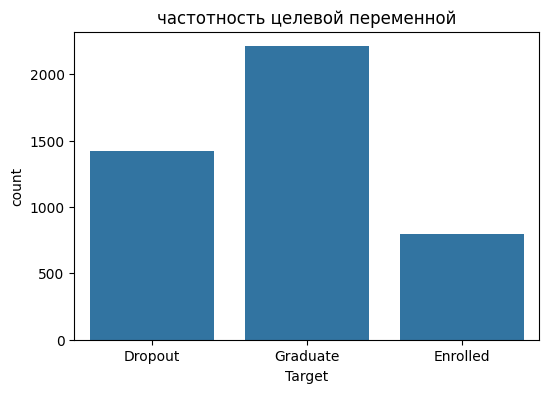

Target
Graduate    0.499322
Dropout     0.321203
Enrolled    0.179476
Name: proportion, dtype: float64

In [157]:
plt.figure(figsize=(6,4))
sns.countplot(x="Target", data=data)
plt.title("частотность целевой переменной")
plt.show()

data["Target"].value_counts(normalize=True)

Наблюдается умеренный дисбаланс классов. При обучении модели необходимо использовать стратифицированное разбиение.

In [158]:
data.columns

Index(['Marital status', 'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance\t', 'Previous qualification',
       'Previous qualification (grade)', 'Nacionality',
       'Mother's qualification', 'Father's qualification',
       'Mother's occupation', 'Father's occupation', 'Admission grade',
       'Displaced', 'Educational special needs', 'Debtor',
       'Tuition fees up to date', 'Gender', 'Scholarship holder',
       'Age at enrollment', 'International',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd

### Тип признаков:
- Номинальные 9 штук:
    - Marital Status 
    - Application mode
    - Course
    - Previous qualification
    - Nacionality
    - Mother's qual
    - Father's qual
    - Mother's occ
    - Father's occ	
- Бинарные (0/1) 8:
    - Daytime/evening
    - Displaced
    - Special needs
    - Debtor
    - Tuition fees
    - Gender
    - Scholarship
    - International	
- Порядковые 1:
    - Application order (0-9)	
- Числовые 15:
	- Previous qualification (grade)
    - Admission grade
    - Curricular units grades (1st/2nd)
    - Age at enrollment	
    - Curricular units credited/enrolled/evaluations/approved/without evaluations (1st+2nd)
- Числовые непрерывные 3:
    - Unemployment rate, Inflation rate, GDP
- Целевая:
    - Target (Dropout/Enrolled/Graduate)	

In [159]:
nom_vars = ['Marital status', 'Application mode', 'Course', 'Previous qualification', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation"]
bin_vars = ['Daytime/evening attendance\t', 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'International']
ordinal_vars = ['Application order']
num_vars =['Previous qualification (grade)', 'Admission grade', 'Age at enrollment', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)']
float_num_vars = ['Unemployment rate', 'Inflation rate', 'GDP']

In [160]:
# Проверка кардинальности номинальных признаков
data[nom_vars].nunique().sort_values(ascending=False)

Father's occupation       46
Father's qualification    34
Mother's occupation       32
Mother's qualification    29
Nacionality               21
Application mode          18
Course                    17
Previous qualification    17
Marital status             6
dtype: int64

### Преобразование типов данных

In [161]:
# Счётные признаки (целые по природе) → int
count_vars = [
    'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)',
    'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (without evaluations)',
    'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)',
    'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)',
    'Curricular units 2nd sem (without evaluations)'
]
for col in count_vars:
    data[col] = data[col].astype(int)

# Оценки оставляем float — дробная часть несёт информацию:
# 'Previous qualification (grade)', 'Admission grade',
# 'Curricular units 1st sem (grade)', 'Curricular units 2nd sem (grade)'
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance	                     4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                          4424

Далее преобразуем столбец Target в числовой используя LabelEncoder

In [162]:
le = LabelEncoder()
data["Target"] = le.fit_transform(data["Target"])


print(data.head(20)["Target"])
print(le.inverse_transform(data.head(20)["Target"]))




0     0
1     2
2     0
3     2
4     2
5     2
6     2
7     0
8     2
9     0
10    2
11    2
12    0
13    2
14    2
15    0
16    1
17    2
18    2
19    1
Name: Target, dtype: int64
['Dropout' 'Graduate' 'Dropout' 'Graduate' 'Graduate' 'Graduate'
 'Graduate' 'Dropout' 'Graduate' 'Dropout' 'Graduate' 'Graduate' 'Dropout'
 'Graduate' 'Graduate' 'Dropout' 'Enrolled' 'Graduate' 'Graduate'
 'Enrolled']


### **Проверка "очищенных" данных**

In [163]:
data.duplicated().sum()

np.int64(0)

In [164]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance	                     4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                          4424

In [165]:
data.head(10)

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,0
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,2
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,0
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,2
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,2
5,2,39,1,9991,0,19,133.1,1,37,37,...,0,5,17,5,11.500000,5,16.2,0.3,-0.92,2
6,1,1,1,9500,1,1,142.0,1,19,38,...,0,8,8,8,14.345000,0,15.5,2.8,-4.06,2
7,1,18,4,9254,1,1,119.0,1,37,37,...,0,5,5,0,0.000000,0,15.5,2.8,-4.06,0
8,1,1,3,9238,1,1,137.0,62,1,1,...,0,6,7,6,14.142857,0,16.2,0.3,-0.92,2
9,1,1,1,9238,1,1,138.0,1,1,19,...,0,6,14,2,13.500000,0,8.9,1.4,3.51,0


Данные выглядят "чистыми" и готовы к EDA.

## 2. EDA

Общий разведочный анализ: распределения признаков, корреляции, выбросы.

In [166]:
data[num_vars].describe()

,Previous qualification (grade),Admission grade,Age at enrollment,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations)
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,132.613314,126.978119,23.265145,0.709991,6.270570,8.299051,4.706600,10.640822,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316
std,13.188332,14.482001,7.587816,2.360507,2.480178,4.179106,3.094238,4.843663,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774
min,95.000000,95.000000,17.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,125.000000,117.900000,19.000000,0.000000,5.000000,6.000000,3.000000,11.000000,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000
50%,133.100000,126.100000,20.000000,0.000000,6.000000,8.000000,5.000000,12.285714,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000
75%,140.000000,134.800000,25.000000,0.000000,7.000000,10.000000,6.000000,13.400000,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000
max,190.000000,190.000000,70.000000,20.000000,26.000000,45.000000,26.000000,18.875000,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000


In [167]:
imp = ['Marital status', "Course", "Previous qualification", "Admission grade", "Age at enrollment", "Curricular units 1st sem (grade)", "Curricular units 2nd sem (grade)", "GDP", "Target"]

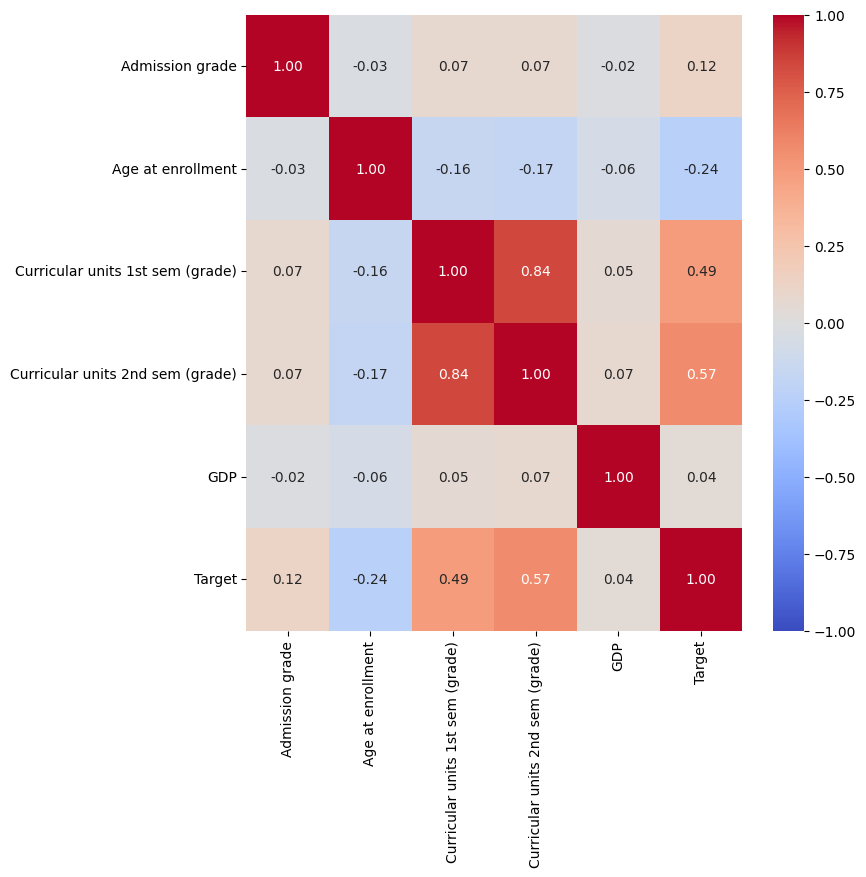

In [168]:
corr = ["Admission grade", "Age at enrollment", "Curricular units 1st sem (grade)", "Curricular units 2nd sem (grade)", "GDP", "Target"]

corr_matrix = data[corr].corr(numeric_only=True)

plt.figure(figsize=(8,8))
sns.heatmap(
    corr_matrix, 
    annot=True,     # Пишем значения внутри ячеек
    cmap='coolwarm', # Цветовая гамма (синий-белый-красный)
    fmt=".2f",      # Формат чисел (2 знака после запятой)
    vmin=-1, vmax=1 # Фиксируем границы цветов (от -1 до 1)
)
plt.show()


### Из тепловой карты мы видим:
- большинство признаков слабо свящанны друг с другом
- нормальную связь имеют признаки семейного статуса и возраста, что очень логично
- сильная зависимость есть у признаков, которые относятся к оценкам и предметам за семестры.
- К целевому признаку умеренно кореллируют тольок сданные предметы в семетрах и все

/var/folders/zb/dsr0j93j6sgd8wplkp6h6x3m0000gn/T/ipykernel_49693/2715876422.py:5: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/feedachyou/Library/Python/3.14/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


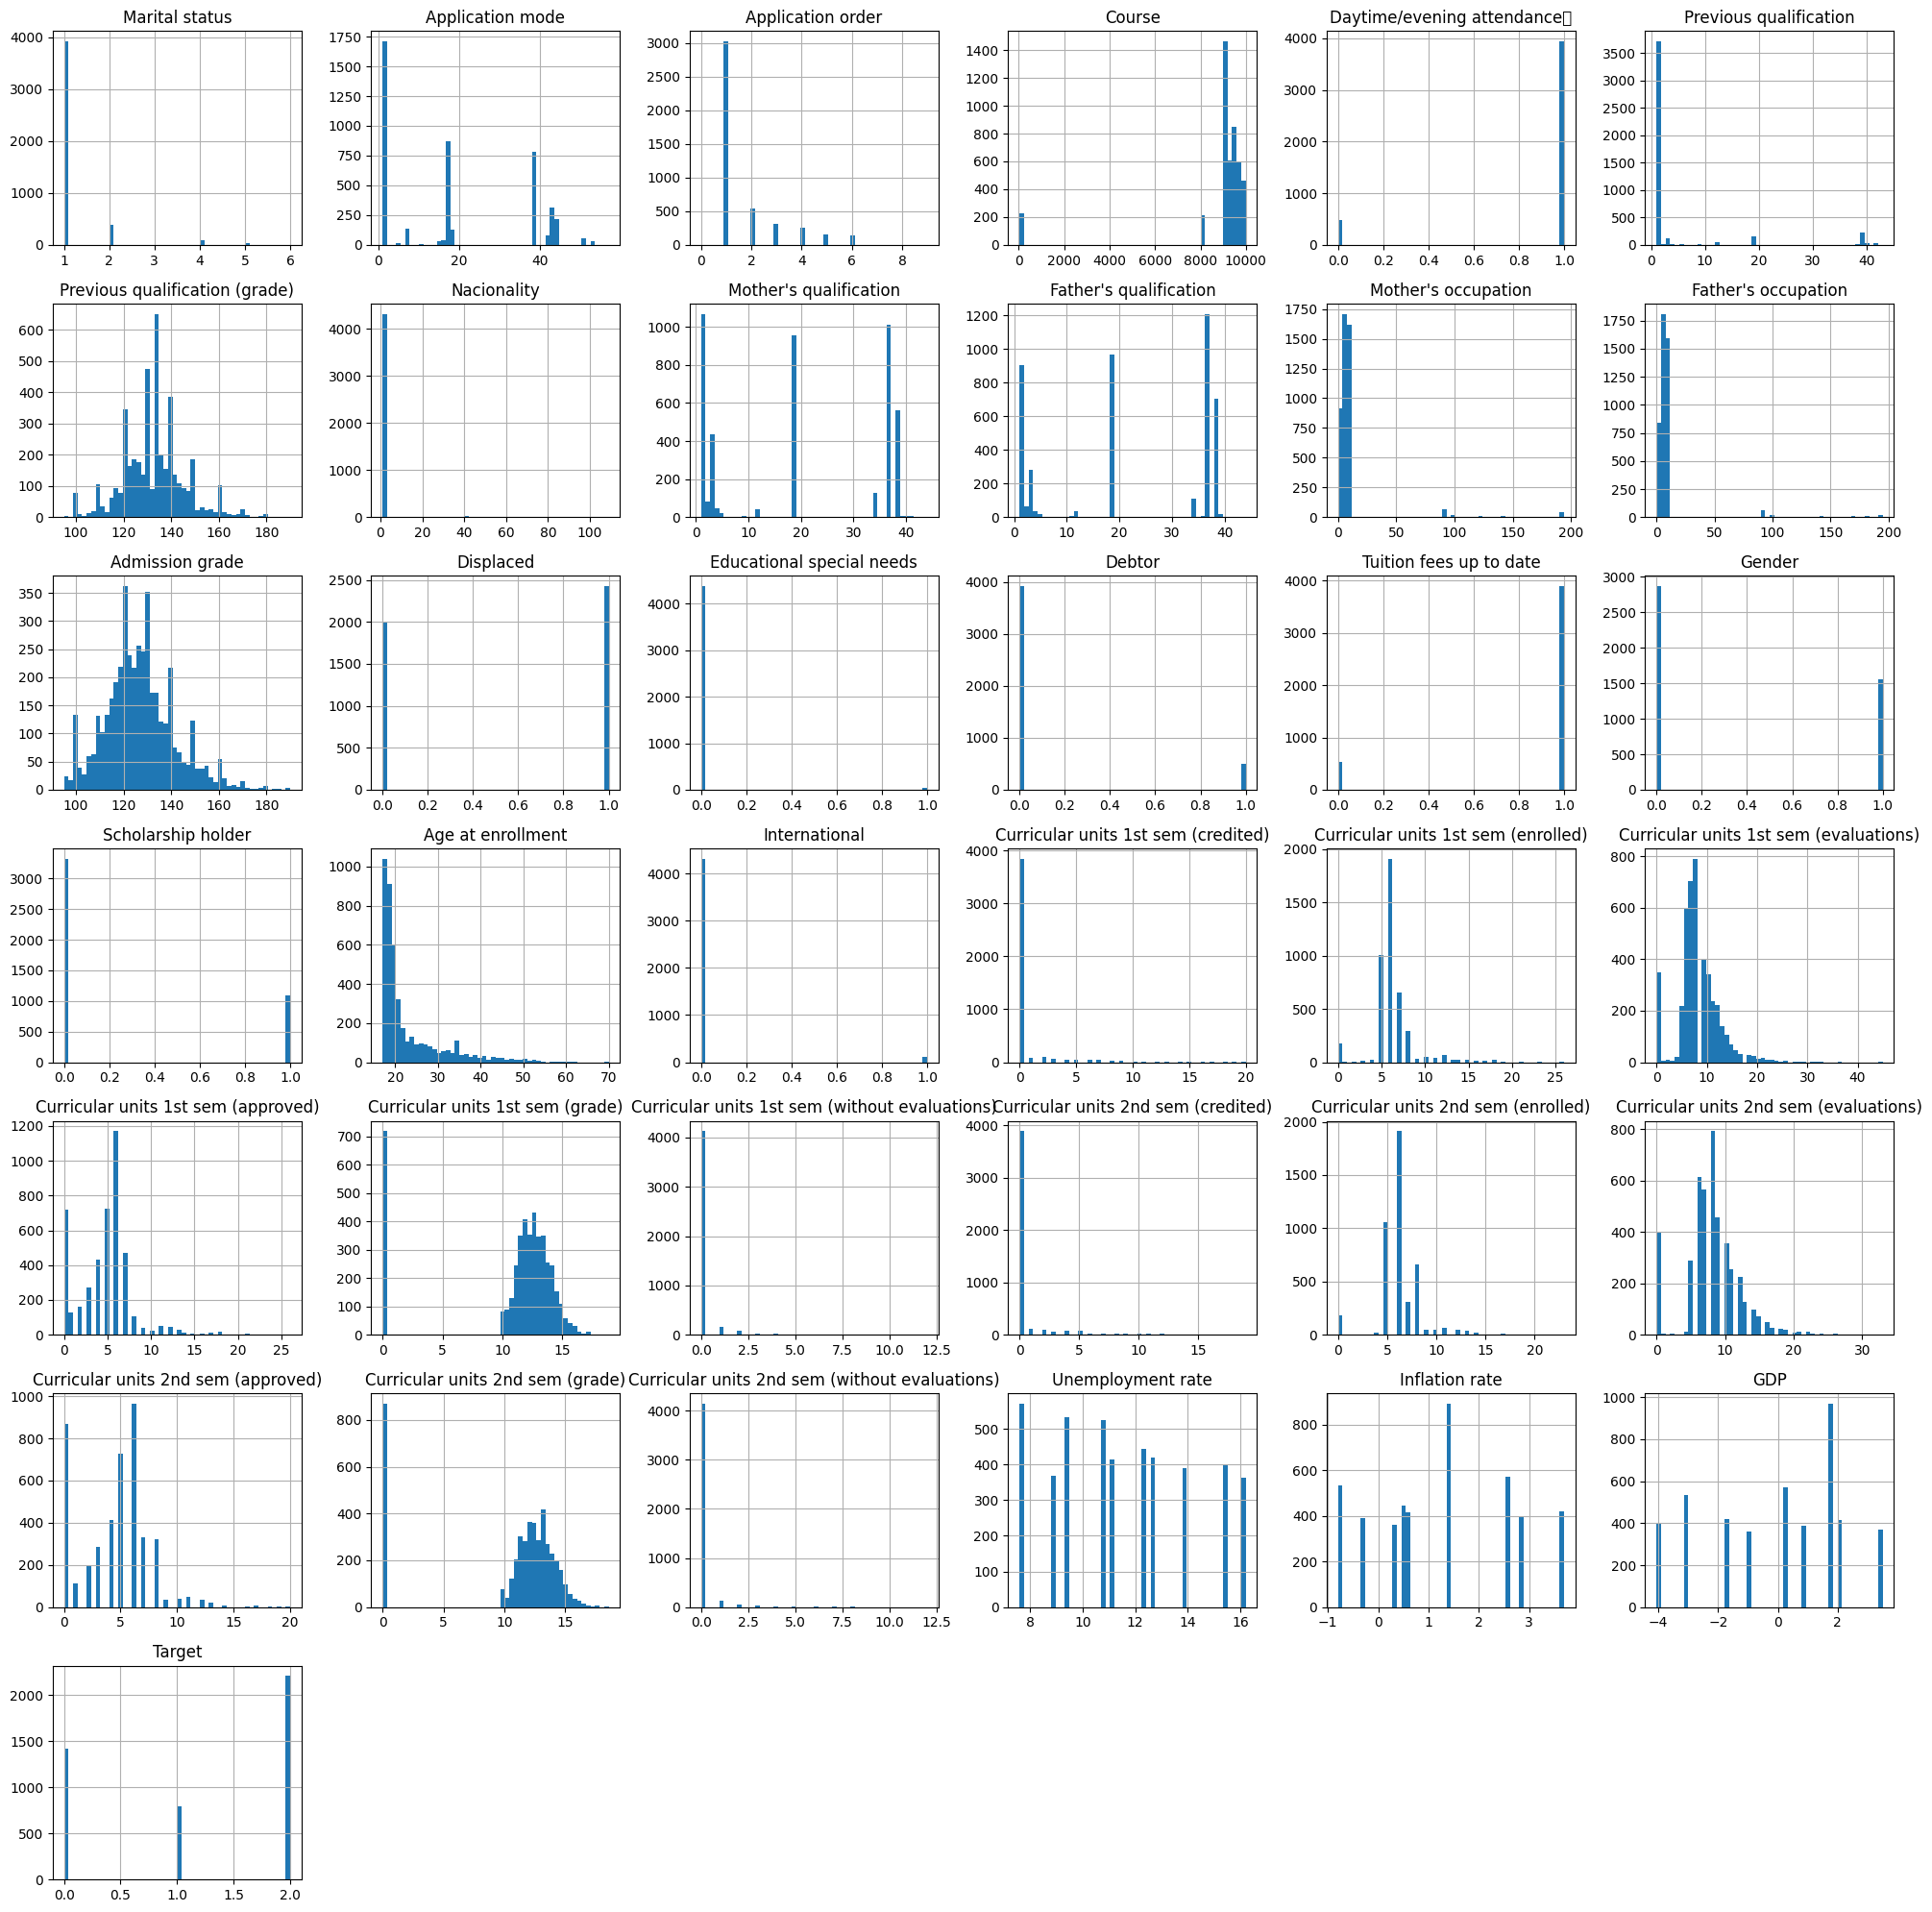

In [169]:
num_imp = ["Admission grade", "Age at enrollment", "Curricular units 1st sem (grade)", "Curricular units 2nd sem (grade)", "GDP"]

num_cols = data.select_dtypes(include=['int64', 'float64']).columns
data.hist(bins=50, figsize=(20, 20))
plt.tight_layout()
plt.show()

Корреляция числовых признаков с Target:
 Target                                            1.000000
Curricular units 2nd sem (approved)               0.624157
Curricular units 2nd sem (grade)                  0.566827
Curricular units 1st sem (approved)               0.529123
Curricular units 1st sem (grade)                  0.485207
Tuition fees up to date                           0.409827
Scholarship holder                                0.297595
Curricular units 2nd sem (enrolled)               0.175847
Curricular units 1st sem (enrolled)               0.155974
Admission grade                                   0.120889
Displaced                                         0.113986
Previous qualification (grade)                    0.103764
Curricular units 2nd sem (evaluations)            0.092721
Application order                                 0.089791
Daytime/evening attendance\t                      0.075107
Curricular units 2nd sem (credited)               0.054004
Curricular unit

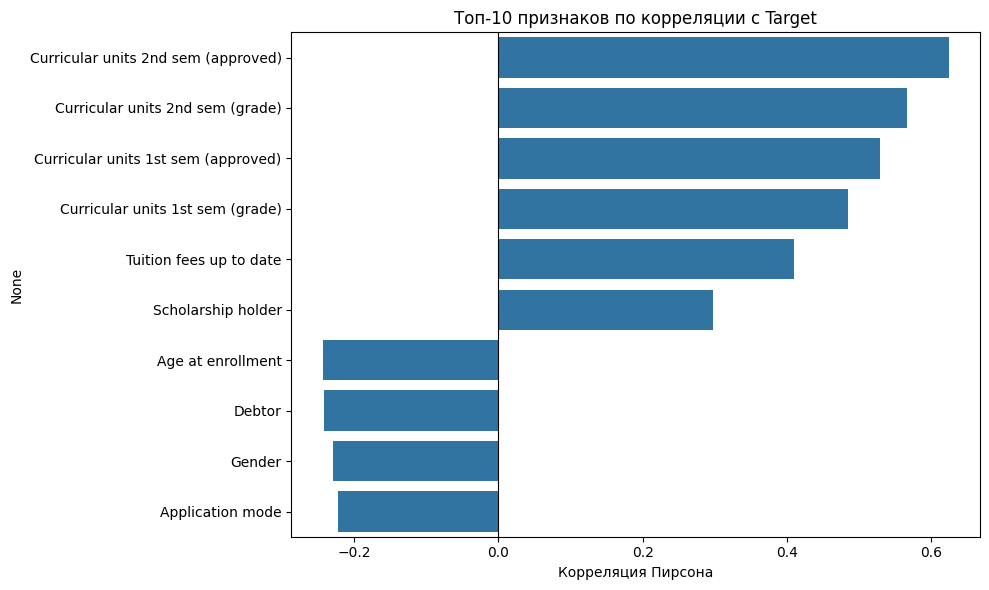

In [170]:
corr_with_target = data.corr(numeric_only=True)['Target'].sort_values(ascending=False)
print("Корреляция числовых признаков с Target:\n", corr_with_target)

top_features = corr_with_target.drop('Target').abs().sort_values(ascending=False).head(10).index
plt.figure(figsize=(10, 6))
sns.barplot(x=corr_with_target[top_features].values, y=top_features)
plt.title('Топ-10 признаков по корреляции с Target')
plt.xlabel('Корреляция Пирсона')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

### Из графиков мы видим:
- средний балл распределен примерно равномерно
- выбросы мешают рассмотреть большинство числовых признаков
- категороиальыне признаки распределены эксмпоненциально

### Обработаем эти признаки на выбросы

In [171]:
outlier_cols = [
    'Admission grade', 'Age at enrollment',
    'Curricular units 1st sem (grade)', 'Curricular units 2nd sem (grade)',
    'Unemployment rate', 'Inflation rate', 'GDP'
]
outlier = data[outlier_cols]
outlier

,Admission grade,Age at enrollment,Curricular units 1st sem (grade),Curricular units 2nd sem (grade),Unemployment rate,Inflation rate,GDP
0,127.3,20,0.000000,0.000000,10.8,1.4,1.74
1,142.5,19,14.000000,13.666667,13.9,-0.3,0.79
2,124.8,19,0.000000,0.000000,10.8,1.4,1.74
3,119.6,20,13.428571,12.400000,9.4,-0.8,-3.12
4,141.5,45,12.333333,13.000000,13.9,-0.3,0.79
...,...,...,...,...,...,...,...
4419,122.2,19,13.600000,12.666667,15.5,2.8,-4.06
4420,119.0,18,12.000000,11.000000,11.1,0.6,2.02
4421,149.5,30,14.912500,13.500000,13.9,-0.3,0.79
4422,153.8,20,13.800000,12.000000,9.4,-0.8,-3.12


In [172]:
# Определить нижние пределы для выбросов
Q1 = outlier.quantile(0.25)
Q1


Admission grade                     117.90
Age at enrollment                    19.00
Curricular units 1st sem (grade)     11.00
Curricular units 2nd sem (grade)     10.75
Unemployment rate                     9.40
Inflation rate                        0.30
GDP                                  -1.70
Name: 0.25, dtype: float64

In [173]:
# Определить верхние пределы выбросов
Q3 = outlier.quantile(0.75)
Q3

Admission grade                     134.800000
Age at enrollment                    25.000000
Curricular units 1st sem (grade)     13.400000
Curricular units 2nd sem (grade)     13.333333
Unemployment rate                    13.900000
Inflation rate                        2.600000
GDP                                   1.790000
Name: 0.75, dtype: float64

In [174]:
# IQR-оценки
IQR = Q3-Q1
# Отфильтрованные данные, из которых удалены выбросы
data_filtered = outlier[~((outlier < (Q1 - 1.5 * IQR)) |(outlier > (Q3 + 1.5 * IQR))).any(axis=1)]
data_filtered

,Admission grade,Age at enrollment,Curricular units 1st sem (grade),Curricular units 2nd sem (grade),Unemployment rate,Inflation rate,GDP
1,142.5,19,14.000000,13.666667,13.9,-0.3,0.79
3,119.6,20,13.428571,12.400000,9.4,-0.8,-3.12
6,128.4,18,13.300000,14.345000,15.5,2.8,-4.06
8,129.3,21,13.875000,14.142857,16.2,0.3,-0.92
9,123.0,18,11.400000,13.500000,8.9,1.4,3.51
...,...,...,...,...,...,...,...
4419,122.2,19,13.600000,12.666667,15.5,2.8,-4.06
4420,119.0,18,12.000000,11.000000,11.1,0.6,2.02
4421,149.5,30,14.912500,13.500000,13.9,-0.3,0.79
4422,153.8,20,13.800000,12.000000,9.4,-0.8,-3.12


#### Копирование индексов


In [175]:
index_list = list(data_filtered.index.values)

In [176]:
# Хранить данные без выбросов в отдельном DataFrame.
data_filtered = data[data.index.isin(index_list)]
data_filtered.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,2
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,2
6,1,1,1,9500,1,1,142.0,1,19,38,...,0,8,8,8,14.345000,0,15.5,2.8,-4.06,2
8,1,1,3,9238,1,1,137.0,62,1,1,...,0,6,7,6,14.142857,0,16.2,0.3,-0.92,2
9,1,1,1,9238,1,1,138.0,1,1,19,...,0,6,14,2,13.500000,0,8.9,1.4,3.51,0


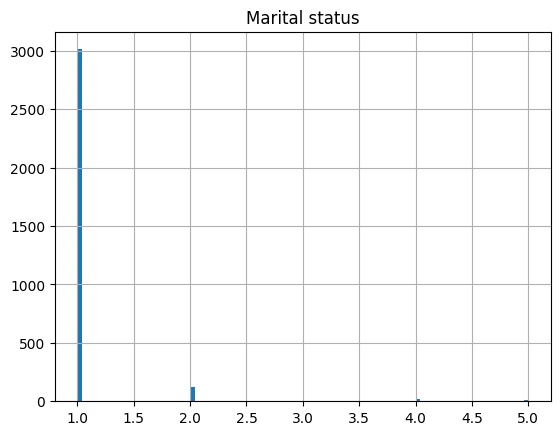

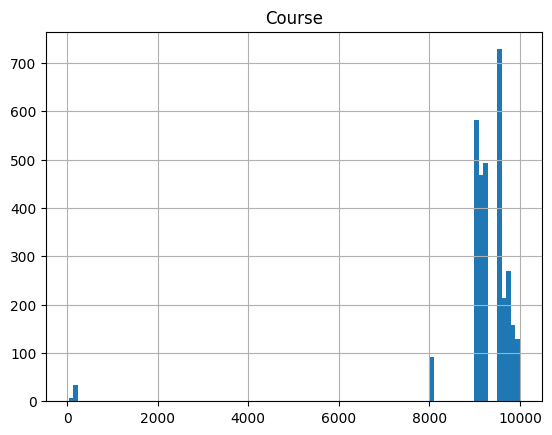

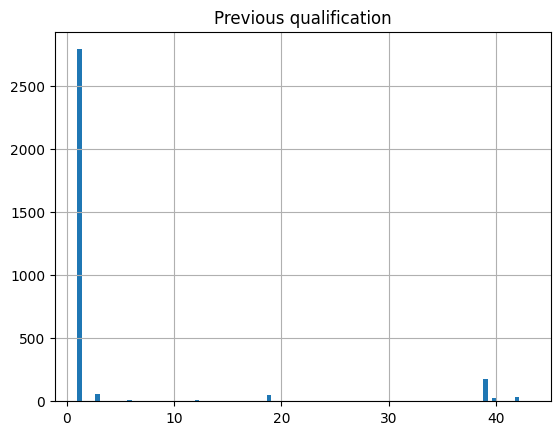

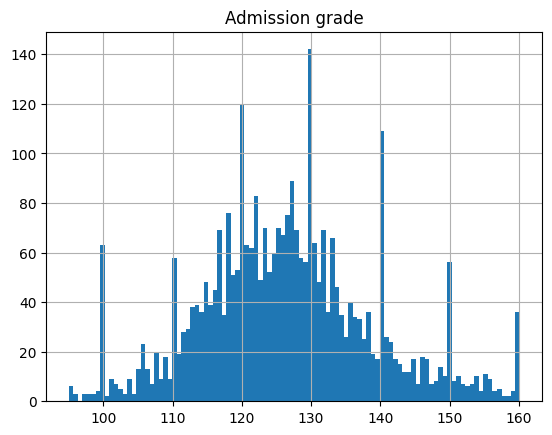

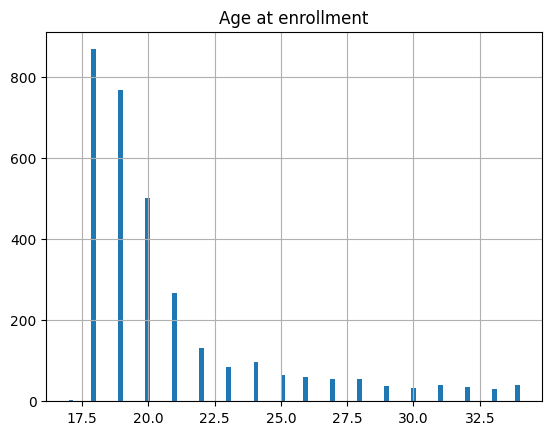

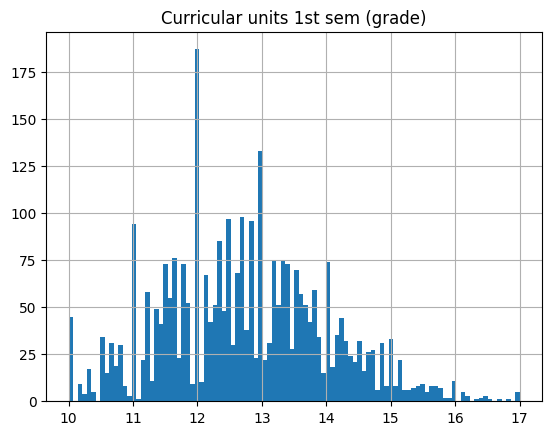

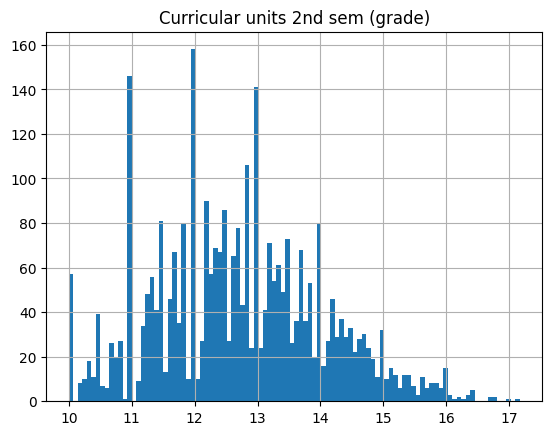

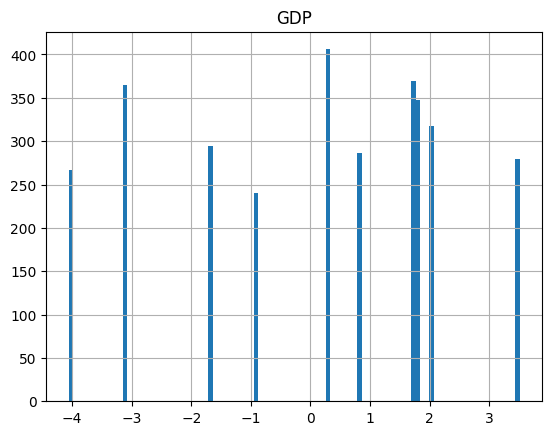

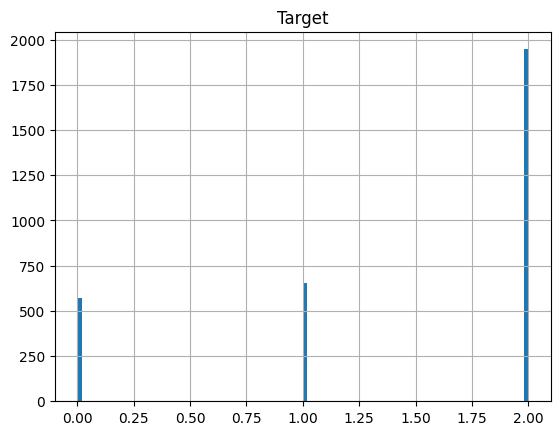

In [177]:
# создать гистограмму с отфильтрованным выбросом
filtered_outlier = data_filtered[imp]

for col in filtered_outlier:
    data_filtered.hist(col, bins=100)

**Заключение:**
- Определили нижний и верхний пределы выбросов, определив 25-й и 75-й процентили. Затем нашли межквартильный размах. Использовали эту информацию для фильтрации выбросов. После удаления выбросов график выглядит более симметричным по сравнению с выбросами, и в данных легче наблюдать среднее значение, медиану и моду.
- В числовых признаках наблюдаются выбросы, однако они могут отражать реальные особенности данных (например, возраст нетипичных студентов), поэтому было принято решение их сохранить.
- Наибольшее количество сданных предметов это около 12, распределены нормально, но левее относительно центра
- Возраст распределен экспонинциально, большая часть распределена до 22-25 дет
- GPD распределен равномерно 
- 'Marital status', "Previous qualification" по сути полностью состоят из одного значения

## 3. Анализ признаков относительно Target

### Числовые признаки относительно Target

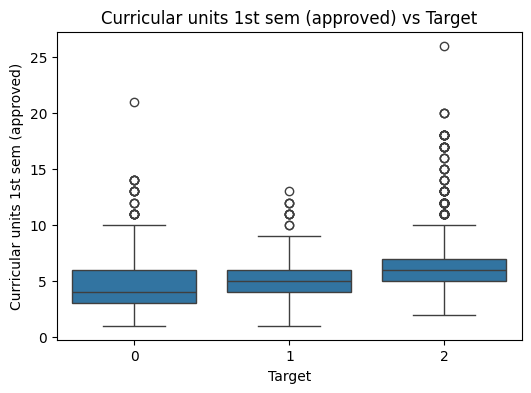

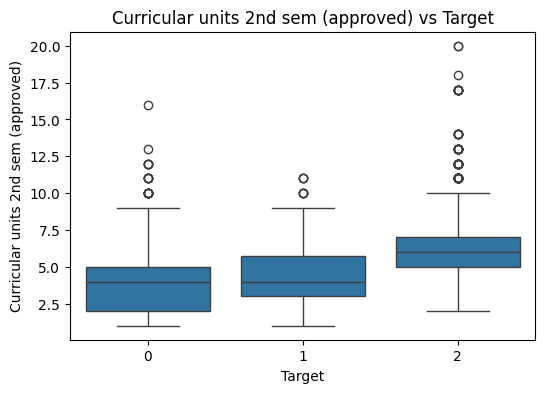

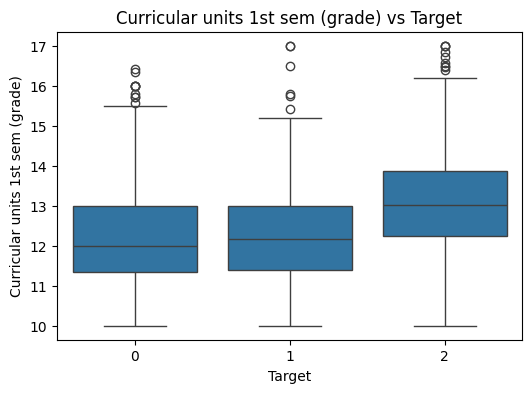

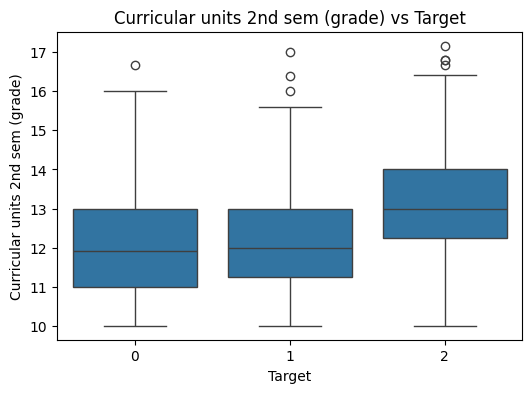

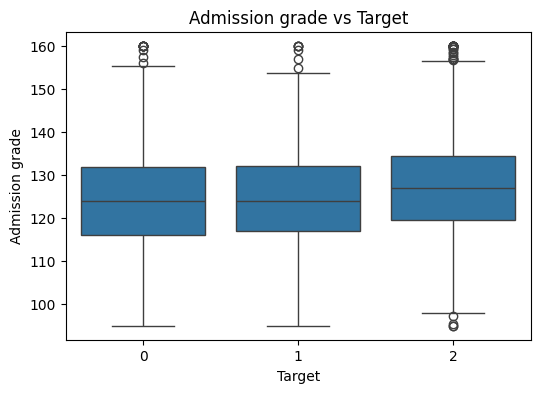

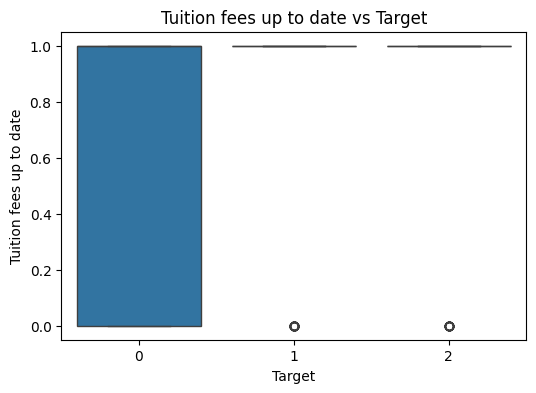

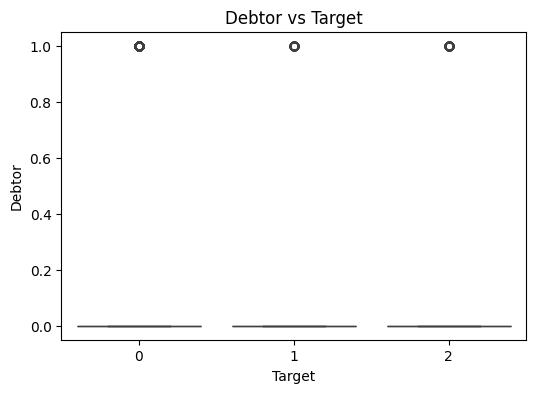

In [178]:
num_tar = ["Curricular units 1st sem (approved)", "Curricular units 2nd sem (approved)", "Curricular units 1st sem (grade)", "Curricular units 2nd sem (grade)", "Admission grade", "Tuition fees up to date", "Debtor"]


for col in num_tar:
    plt.figure(figsize=(6,4))
    sns.boxplot(x="Target", y=col, data=data_filtered)
    plt.title(f"{col} vs Target")
    plt.show()

In [179]:
data_filtered.groupby("Target")[num_vars].mean()

,Previous qualification (grade),Admission grade,Age at enrollment,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations)
Target,,,,,,,,,,,,,,,
0,130.731699,124.625394,22.479860,1.101576,6.591944,10.187391,4.670753,12.171583,0.131349,0.837128,6.478109,10.127846,4.056042,12.060672,0.173380
1,130.703823,124.966055,21.006116,0.484709,6.185015,9.691131,4.733945,12.232744,0.145260,0.328746,6.174312,9.885321,4.428135,12.143816,0.159021
2,133.725180,127.658479,20.275951,0.710689,6.814491,8.437307,6.361254,13.084992,0.084789,0.571429,6.825797,8.377184,6.352004,13.126908,0.078109


Анализ бинарников

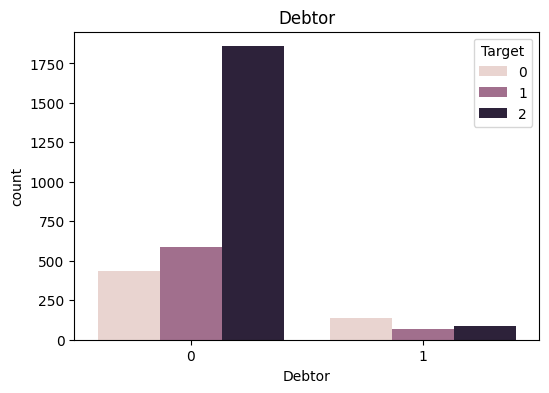

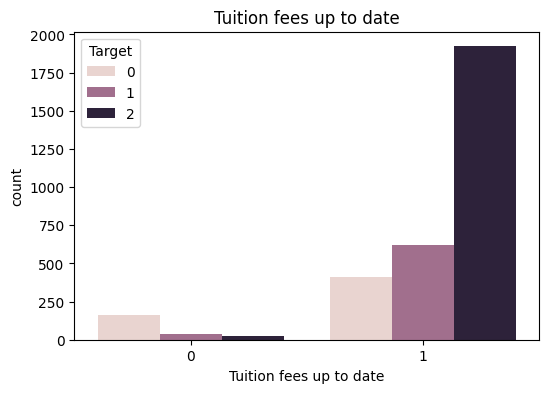

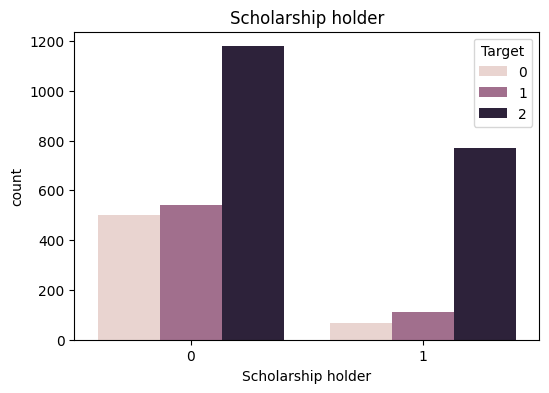

In [180]:
binary_cols = [
    "Debtor",
    "Tuition fees up to date",
    "Scholarship holder"
]

for col in binary_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, hue="Target", data=data_filtered)
    plt.title(col)
    plt.show()

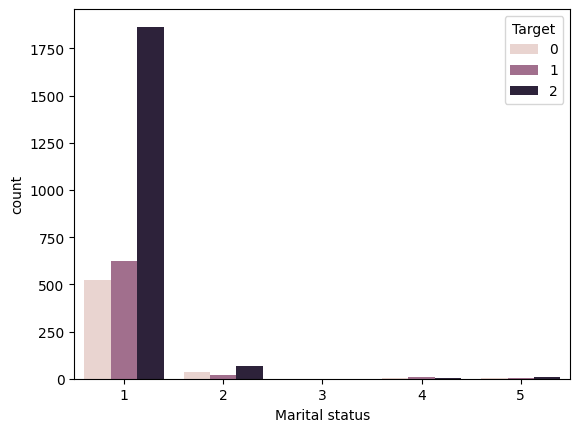

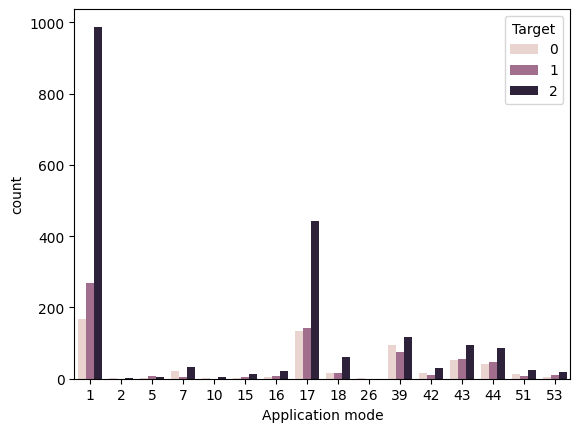

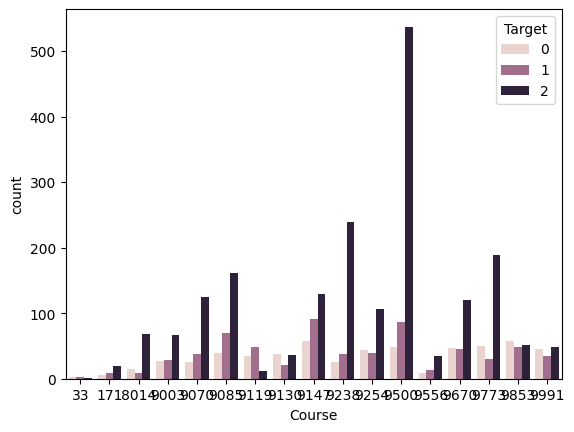

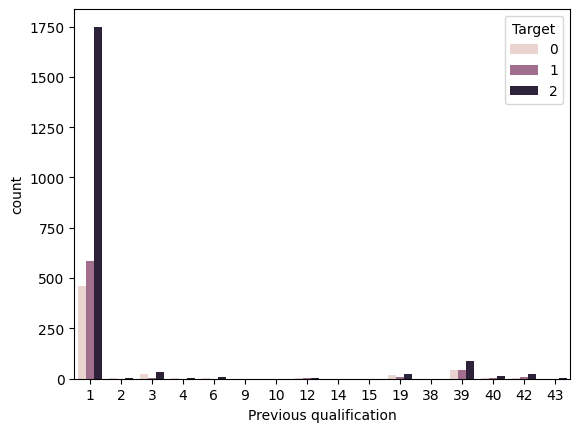

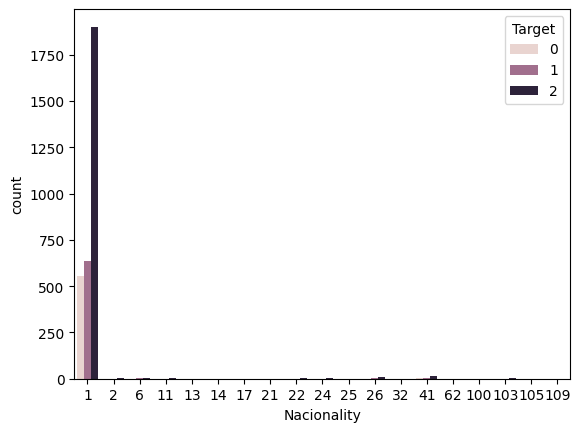

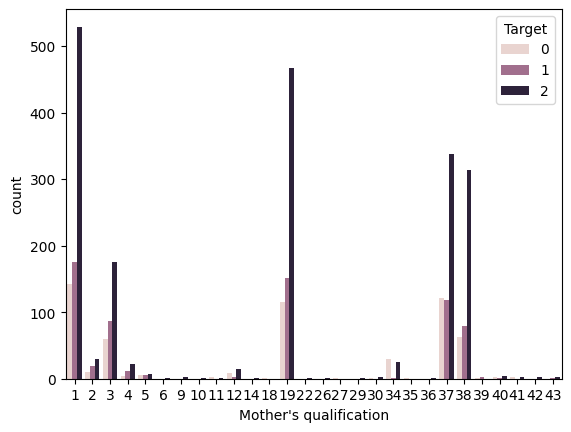

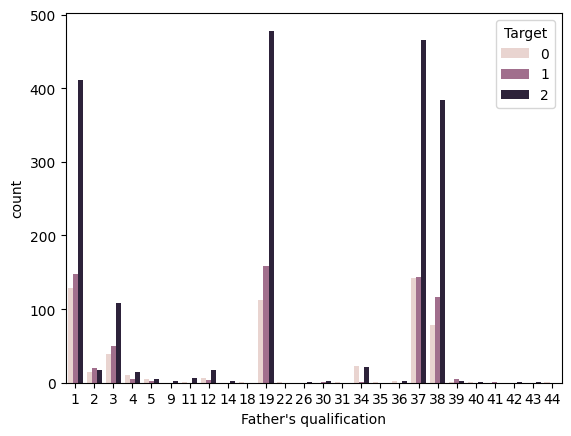

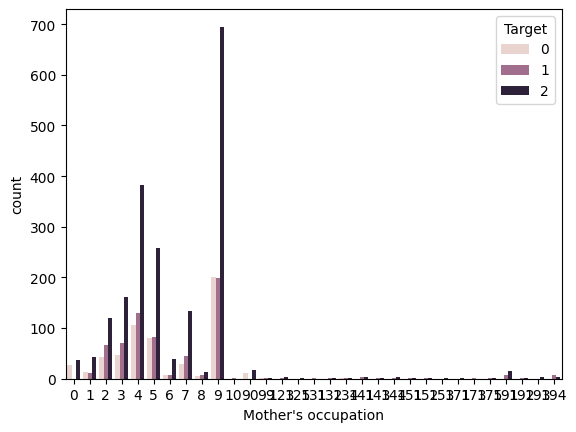

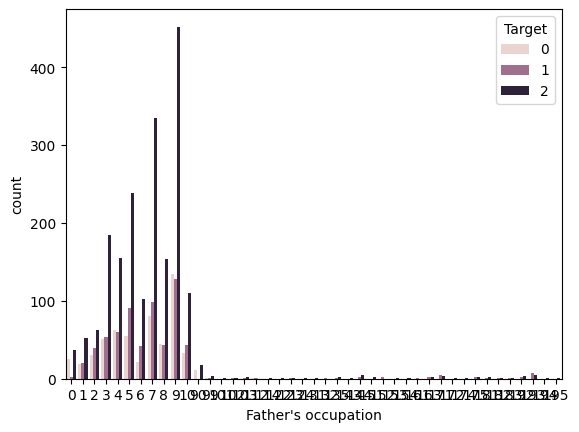

In [181]:
for col in nom_vars:
    sns.countplot(x=col, hue="Target", data=data_filtered)
    plt.show()

- Судя по данным у нас нет категории где аномально большое число отчисленных

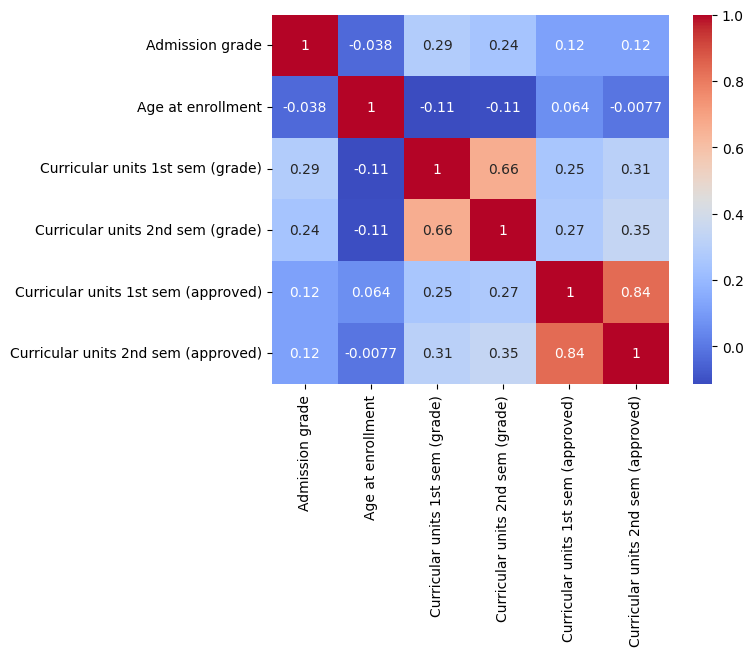

In [182]:
num_cols = [
    "Admission grade",
    "Age at enrollment",
    "Curricular units 1st sem (grade)",
    "Curricular units 2nd sem (grade)",
    "Curricular units 1st sem (approved)",
    "Curricular units 2nd sem (approved)"
]

sns.heatmap(data_filtered[num_cols].corr(), annot=True, cmap="coolwarm")
plt.show()

### Анализ Course к целевой

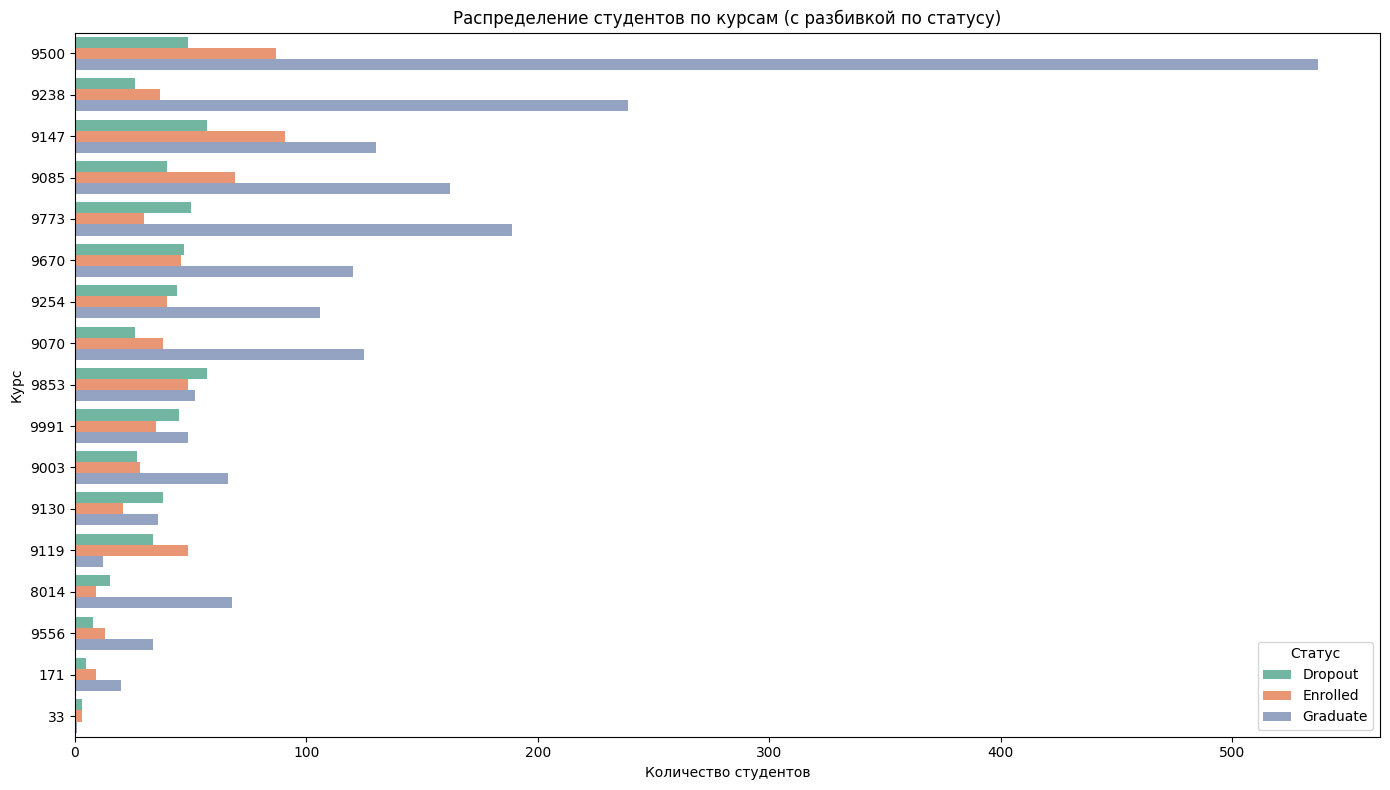

In [183]:
plt.figure(figsize=(14, 8))

# Сортируем курсы по убыванию количества студентов, чтобы график был читаем
order = data_filtered['Course'].value_counts().index

sns.countplot(
    data=data_filtered,
    y='Course',          # горизонтальный вариант, чтобы уместились названия
    hue='Target',
    order=order,
    palette='Set2'
)

plt.title('Распределение студентов по курсам (с разбивкой по статусу)')
plt.xlabel('Количество студентов')
plt.ylabel('Курс')
plt.legend(title='Статус', labels=['Dropout', 'Enrolled', 'Graduate'])
plt.tight_layout()
plt.show()

In [184]:
# Группировка по курсу и статусу
course_status = data_filtered.groupby(['Course', 'Target']).size().unstack(fill_value=0)

# Переименуем столбцы для наглядности
course_status.columns = ['Dropout', 'Enrolled', 'Graduate']

# Добавим общее число студентов на курсе
course_status['Total'] = course_status.sum(axis=1)

# Рассчитаем доли (в процентах)
course_status['Dropout_%'] = (course_status['Dropout'] / course_status['Total']) * 100
course_status['Graduate_%'] = (course_status['Graduate'] / course_status['Total']) * 100
course_status['Enrolled_%'] = (course_status['Enrolled'] / course_status['Total']) * 100

# Отсортируем по убыванию доли отчислений
course_status_sorted = course_status.sort_values('Dropout_%', ascending=False)

# Выведем топ-10 курсов с наибольшей долей отчислений
print(course_status_sorted[['Total', 'Dropout_%', 'Graduate_%', 'Enrolled_%']].head(10))

        Total  Dropout_%  Graduate_%  Enrolled_%
Course                                          
33          7  42.857143   14.285714   42.857143
9130       95  40.000000   37.894737   22.105263
9853      158  36.075949   32.911392   31.012658
9119       95  35.789474   12.631579   51.578947
9991      129  34.883721   37.984496   27.131783
9254      190  23.157895   55.789474   21.052632
9003      121  22.314050   54.545455   23.140496
9670      213  22.065728   56.338028   21.596244
9147      278  20.503597   46.762590   32.733813
9773      269  18.587361   70.260223   11.152416


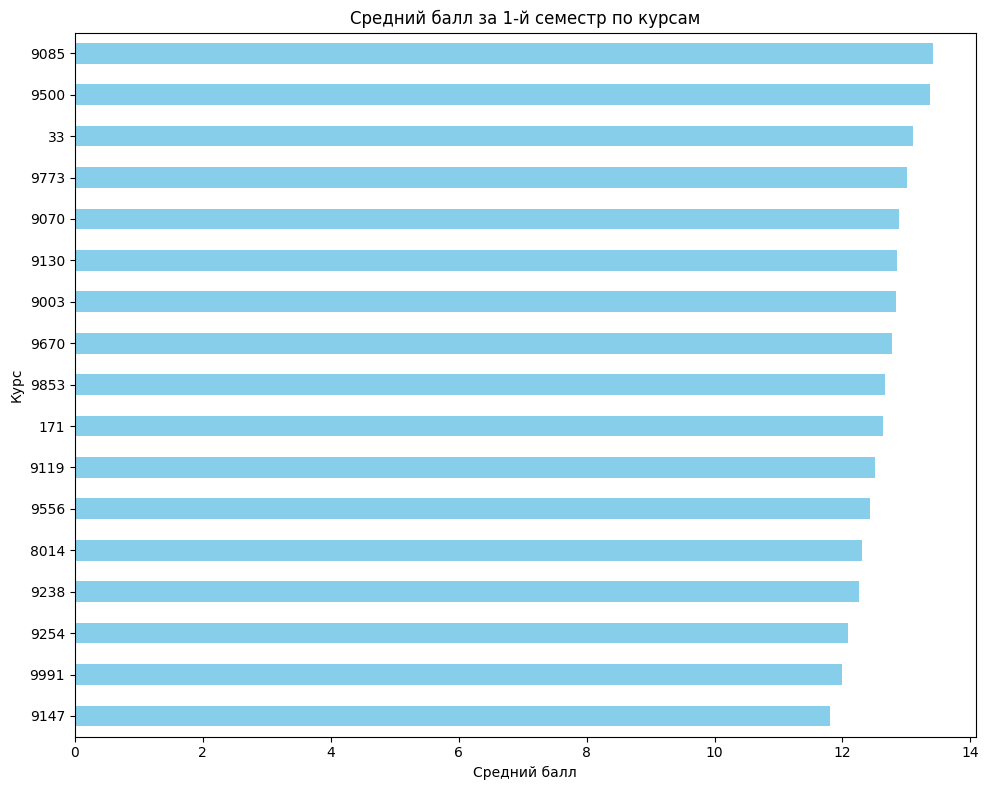

In [185]:
# Рассчитаем средний балл за первый семестр по каждому курсу
avg_grade_by_course = data_filtered.groupby('Course')['Curricular units 1st sem (grade)'].mean().sort_values()

plt.figure(figsize=(10, 8))
avg_grade_by_course.plot(kind='barh', color='skyblue')
plt.title('Средний балл за 1-й семестр по курсам')
plt.xlabel('Средний балл')
plt.ylabel('Курс')
plt.tight_layout()
plt.show()

#### Анализ распределения студентов и их успеваемости по различным курсам выявил значительные различия:

Высокорисковые курсы: курсы с кодами 33 (Биотопливные технологии), 9119 (Информационная инженерия) и 9130 (Эквикультура) имеют критически высокий процент отчислений – от 38% до 50%. Это указывает на потенциальные проблемы с образовательными программами или набором студентов на этих направлениях. Особенно выделяется курс 33, где половина студентов бросает учёбу.

Курс с наибольшим числом "застрявших" студентов: на курсе 9119 (Информационная инженерия) почти половина студентов (48.5%) всё ещё обучаются (статус Enrolled), что может свидетельствовать о высокой сложности программы и большом количестве пересдач.

Курсы-лидеры по успешному окончанию: курсы 9773 (Журналистика и коммуникации) и 9254 (Туризм) показывают лучшие результаты – 69.6% и 56.7% выпускников соответственно при относительно низком проценте отчислений.

## 4. Финальная подготовка данных

Кодируем номинальные признаки методом **One-Hot Encoding** (drop_first=True — избегаем dummy-trap).  
Применяем к `data_filtered` — датасету без выбросов.

In [186]:
# Схлопнуть редкие категории в 'Other' (< 1% от выборки)
def collapse_rare(df, cols, threshold=0.01):
    df = df.copy()
    for col in cols:
        freq = df[col].value_counts(normalize=True)
        rare_cats = freq[freq < threshold].index
        df[col] = df[col].where(~df[col].isin(rare_cats), other='Other')
        print(f"{col}: {len(rare_cats)} редких категорий → {df[col].nunique()} уникальных")
    return df

data_filtered = collapse_rare(data_filtered, nom_vars, threshold=0.01)

Marital status: 3 редких категорий → 3 уникальных
Application mode: 5 редких категорий → 12 уникальных
Course: 1 редких категорий → 17 уникальных
Previous qualification: 11 редких категорий → 6 уникальных
Nacionality: 18 редких категорий → 2 уникальных
Mother's qualification: 20 редких категорий → 9 уникальных
Father's qualification: 19 редких категорий → 8 уникальных
Mother's occupation: 22 редких категорий → 10 уникальных
Father's occupation: 32 редких категорий → 12 уникальных


In [187]:
# One-Hot Encoding номинальных признаков
nom_vars_ohe = [c for c in nom_vars if c != 'Nacionality']                                                            
data_final = pd.get_dummies(data_filtered, columns=nom_vars_ohe, drop_first=True)                        
# Nacionality тоже убираем — дублирует International                                                                  
data_final = data_final.drop(columns=['Nacionality'], errors='ignore')  

print(f'До OHE:    {data_filtered.shape}')
print(f'После OHE: {data_final.shape}')
data_final.head()

До OHE:    (3171, 37)
После OHE: (3171, 97)


,Application order,Daytime/evening attendance\t,Previous qualification (grade),Admission grade,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,...,Father's occupation_2,Father's occupation_3,Father's occupation_4,Father's occupation_5,Father's occupation_6,Father's occupation_7,Father's occupation_8,Father's occupation_9,Father's occupation_10,Father's occupation_Other
1,1,1,160.0,142.5,1,0,0,0,1,0,...,False,True,False,False,False,False,False,False,False,False
3,2,1,122.0,119.6,1,0,0,1,0,0,...,False,True,False,False,False,False,False,False,False,False
6,1,1,142.0,128.4,1,0,0,1,0,1,...,False,False,False,False,False,False,False,False,True,False
8,3,1,137.0,129.3,0,0,0,1,0,1,...,False,False,False,False,False,False,False,True,False,False
9,1,1,138.0,123.0,1,0,1,0,0,0,...,False,False,False,False,False,True,False,False,False,False


In [188]:
data_final.to_csv("stud_end.csv", index=False)
print(f"Сохранено: stud_end.csv  {data_final.shape}")

Сохранено: stud_end.csv  (3171, 97)


### Итоговый вывод EDA

**Предобработка:**
- Пропуски и дубликаты отсутствуют
- Счётные признаки переведены в `int`, оценки оставлены как `float`
- `Target` закодирован через `LabelEncoder` (Dropout=0, Enrolled=1, Graduate=2)
- Выбросы определены по IQR для 7 числовых признаков (оценки, возраст, макроэкономика)
- Номинальные признаки (9 шт.) закодированы через One-Hot Encoding

**Ключевые выводы:**
- Умеренный дисбаланс классов (~32% Dropout, ~50% Graduate, ~18% Enrolled) — при обучении модели использовать `stratify=y`
- Наиболее значимые для предсказания: оценки за семестры, число сданных предметов, вступительный балл
- Между оценками 1-го и 2-го семестра высокая корреляция — возможна мультиколлинеарность
- Курсы с наибольшим процентом отчислений: код 33 (~50%), код 9119 (~49%)